In [51]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [52]:
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (224, 224))

In [53]:
# DFT (주파수 변환)
def dft_image(img):
    dft = np.fft.fft2(img)              # 2D 푸리에 변환
    dft_shift = np.fft.fftshift(dft)    # 중심을 이미지 중앙으로 이동
    return dft_shift

# IDFT (역변환)
def idft_image(dft_shift):
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)         # 복소수 → 실수
    return img_back

In [54]:
# Low Pass Filter 생성
def low_pass_filter(shape, radius):
    mask = np.zeros(shape, np.uint8)
    center = (shape[0]//2, shape[1]//2)
    for i in range(shape[0]):
        for j in range(shape[1]):
            if np.sqrt((i - center[0])**2 + (j - center[1])**2) <= radius:
                mask[i, j] = 1
    return mask

# High Pass Filter 생성 (1 - Low-pass)
def high_pass_filter(shape, radius):
    return 1 - low_pass_filter(shape, radius)

In [55]:
# DFT 수행
dft_shift = dft_image(img)

# 필터 마스크 생성
radius = 20  # 필터 반지름
low_pass_mask = low_pass_filter(img.shape, radius)
high_pass_mask = high_pass_filter(img.shape, radius)

In [56]:
# 역변환
img_low = idft_image(dft_shift * low_pass_mask)
img_high = idft_image(dft_shift * high_pass_mask)

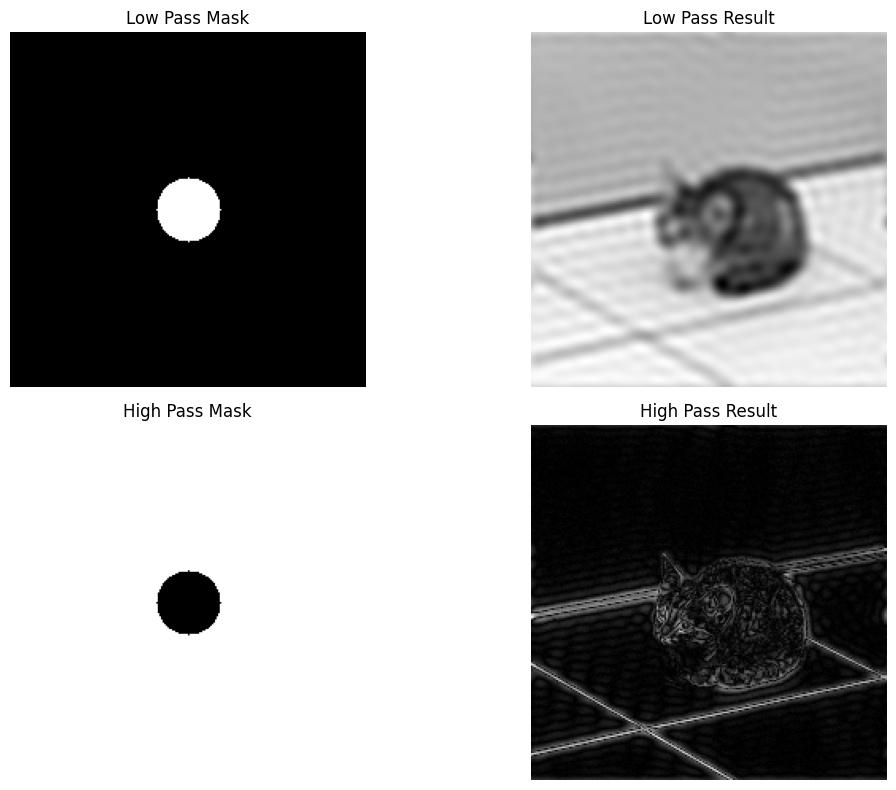

In [57]:
# 결과 출력력
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(low_pass_mask*255, cmap='gray')
plt.title("Low Pass Mask")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_low, cmap='gray')
plt.title("Low Pass Result")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(high_pass_mask*255, cmap='gray')
plt.title("High Pass Mask")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_high, cmap='gray')
plt.title("High Pass Result")
plt.axis('off')

plt.tight_layout()
plt.show()
